In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [20]:
clean_path = "../../data/cleaned_wells.csv"
link_path = "../../data/link_table.csv"

df = pd.read_csv(clean_path)
link_df = pd.read_csv(link_path)

df.head(), link_df.head()


(   OBJ_ID  Permit number - API            Well Type            Well Status  \
 0   98569         3.408360e+13          Plugged gas  Plugged and Abandoned   
 1  230941         3.420000e+13                  Gas           Well Drilled   
 2   36229         3.402960e+13                  Oil           Well Drilled   
 3  182932         3.412760e+13          Plugged oil  Plugged and Abandoned   
 4  176936         3.412720e+13  Plugged oil and gas      Final Restoration   
 
   Well_GIS_Status      County   Township                Company  \
 0         Drilled        KNOX       PIKE         HISTORIC OWNER   
 1         Drilled  WASHINGTON    NEWPORT  SHELLY MATERIALS INC.   
 2         Drilled  COLUMBIANA  MIDDLETON         HISTORIC OWNER   
 3         Drilled       PERRY       PIKE         HISTORIC OWNER   
 4         Drilled       PERRY    JACKSON         GINGERICH MIKE   
 
                                Well_OP_Address Well_CompanyPHONE  Elevation  \
 0  2045 Morse Rd., Bldg F-2 COLUM

In [21]:
CURRENT_YEAR = 2025  # or pd.Timestamp.today().year

df['Last_Nonzero_Production_Year'] = pd.to_numeric(df['Last_Nonzero_Production_Year'], errors='coerce')

df['production_recency'] = CURRENT_YEAR - df['Last_Nonzero_Production_Year']
df['production_recency'] = df['production_recency'].replace([np.inf, -np.inf], np.nan)


In [22]:
link_df = link_df.merge(
    df[['OBJ_ID', 'production_recency']],
    left_on='production_OBJ_ID',
    right_on='OBJ_ID',
    how='left'
)


In [23]:
bins = [0, 1, 3, 5, 10, np.inf]
labels = ["0–1 mile", "1–3 miles", "3–5 miles", "5–10 miles", "10+ miles"]

link_df['distance_band'] = pd.cut(
    link_df['distance_miles'],
    bins=bins,
    labels=labels,
    include_lowest=True
)


In [24]:
summary = link_df.groupby('distance_band')['production_recency'].agg(
    ['mean','median','count']
)

summary


/var/folders/wq/0251_rxs3893xdqcrkc3xwpr0000gn/T/ipykernel_89013/2000012384.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = link_df.groupby('distance_band')['production_recency'].agg(


,mean,median,count
distance_band,,,
0–1 mile,11.489540,3.0,478
1–3 miles,12.293160,5.0,1228
3–5 miles,11.470830,4.0,2194
5–10 miles,11.803048,2.0,2559
10+ miles,NaN,NaN,0


<Figure size 1000x600 with 0 Axes>

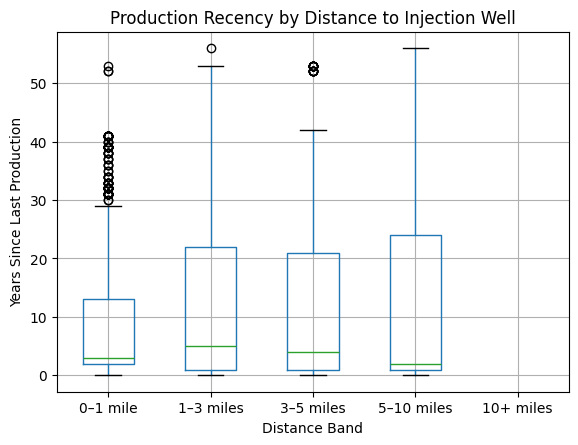

In [25]:
plt.figure(figsize=(10,6))
link_df.boxplot(column='production_recency', by='distance_band')
plt.title("Production Recency by Distance to Injection Well")
plt.suptitle("")
plt.ylabel("Years Since Last Production")
plt.xlabel("Distance Band")
plt.show()


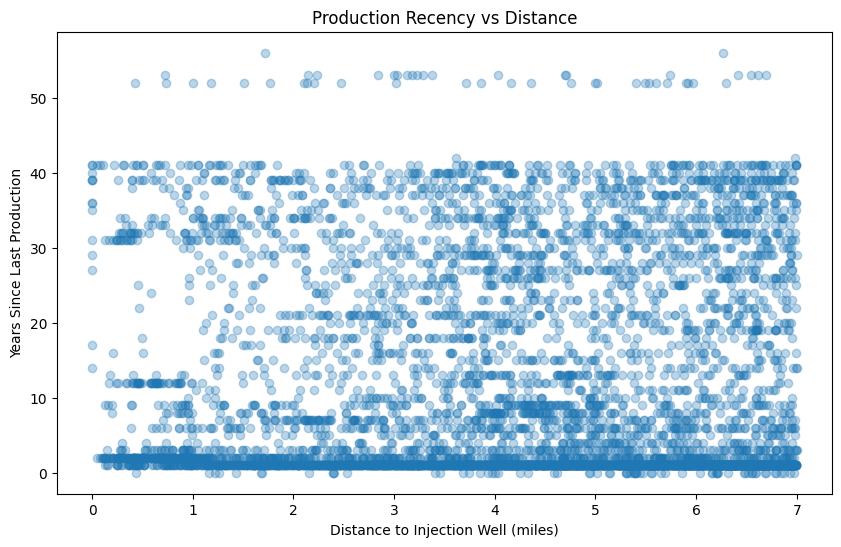

In [26]:
plt.figure(figsize=(10,6))
plt.scatter(link_df['distance_miles'], link_df['production_recency'], alpha=0.3)
plt.xlabel("Distance to Injection Well (miles)")
plt.ylabel("Years Since Last Production")
plt.title("Production Recency vs Distance")
plt.show()
